In [6]:
from time import perf_counter
import numpy as np
import scipy as sp
import pandas as pd
from matplotlib import pyplot as plt

## Reading in the Datasets

### Global Temperature


In [7]:
# Global Temperature
# gt_data = pd.read_csv("datasets/global_temp/GlobalTemperatures.csv")
# gt_data["year"] = gt_data["dt"].str[:4].astype(int)

# gt_data_filtered = []
# for year in np.arange(1750, 2016):
#     gt_year_data = gt_data[gt_data["year"] == year]
#     land_temp = gt_year_data["LandAverageTemperature"].to_numpy()
#     ocean_temp = gt_year_data["LandAndOceanAverageTemperature"].to_numpy()
#     yearly_data = np.array((land_temp, ocean_temp)) # append land and ocean monthly temperatures together
#     gt_data_filtered.append(yearly_data)
#     # print(yearly_data.shape)

# gt_data_filtered = np.dstack(gt_data_filtered)

def get_year(year: int):
    """
    Converts a year to an index offset from 1750.

    Args:
        year (int): A year between 1750 and 2015 inclusive.

    Returns:
        int: The index of the year (e.g. 1750 → 0, 1751 → 1).
    """
    return year - 1750

# np.save("datasets/gt_data_filtered.npy", gt_data_filtered)
gt_data_filtered = np.load("datasets/gt_data_filtered.npy")


# # eg: gt_data_filtered[0, :, get_year(2015)]

# # [ (0, 1) # {0: land temperatures, 1: ocean temperatures}
# #   (0-11) # month of the year
# #   (0-266) # year 1750 - 2015
# #  ]

gt_data_noNaNs = gt_data_filtered[:, :, 100]

def get_year_noNaNs(year: int):
    """
    Converts a year to an index offset from 1850.

    Note: This is for the noNaNs data since the first 100 years have NaNs

    Args:
        year (int): A year between 1850 and 2015 inclusive.

    Returns:
        int: The index of the year (e.g. 1850 → 0, 1851 → 1).
    """
    return year - 1850

gt_data_land_temps = gt_data_filtered[0, :, 3:]

# # eg: gt_data_land_temps[:, get_year_land(1800)] # returns the land average temperatures for every month in the year 1800

# # [ (0-11) # month of the year
# #   (0-263) # year 1753 - 2015
# #  ]

def get_year_land(year: int):
    """
    Converts a year to an index offset from 1753.

    Note: This is for the land temps data since the first 3 years had NaNs for land

    Args:
        year (int): A year between 1753 and 2015 inclusive.

    Returns:
        int: The index of the year (e.g. 1753 → 0, 1754 → 1).
    """
    return year - 1753

### Average Temperature
This dataset contains the average yearly temperature in America, with data gathered from many different locations. It has measurements from 1900-2023.

In [8]:
# Average Temperature
avtemp_df = pd.read_csv("datasets/Average_Temperature_1900_2023.csv", index_col=0)
avtemp_df = avtemp_df.astype(float)  # Setting the temperature datatypes to floats
avtemp_df["temp"] = avtemp_df["Average_Fahrenheit_Temperature"]
avtemp_df = avtemp_df.drop(columns=["Average_Fahrenheit_Temperature"])  # Renaming the column

### C02 and GHG Levels

/var/folders/lj/vn9rfy_94ynbs32_0d7w3_k00000gn/T/ipykernel_13720/3142775796.py:34: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


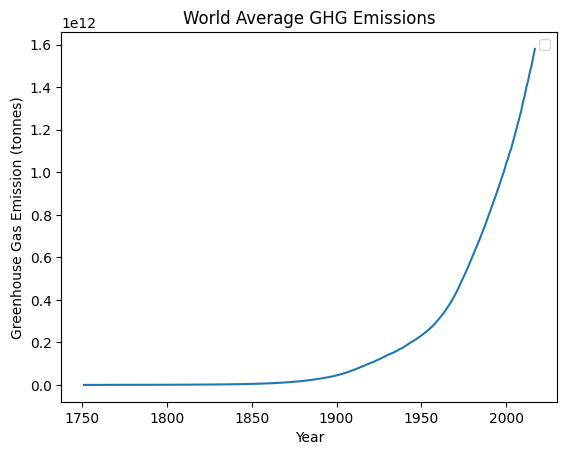

In [9]:
# greenhouse gases dataframe by country. Each row has the greenhouse gas emissions for a country by year
co2ghg_df = pd.read_csv("datasets/co2_ghg.csv")


# ========= I did a lot of work to average out when a country recorded 0... I think the 0s are legit and this dataset seems really clean actually =========

# # add the mean value of the countries that didn't record 0 to those that did record 0 for each year
# co2_nocountries = co2ghg_df.drop(columns="Country")
# year_means = co2_nocountries.replace(0, pd.NA).mean()
# co2ghg_avg0s_df = co2_nocountries.mask(co2_nocountries == 0, year_means, axis="columns")
# co2ghg_avg0s_df.insert(0, "Country", co2ghg_df["Country"])


# # co2ghg_df is the df unaltered
# # co2ghg_avg0s_df is the df with yearly means added to 0 entries
# country_to_filter = "Yemen"
# afghan_co2data = co2ghg_df[co2ghg_df["Country"] == country_to_filter].to_numpy()[0][1:]
# afghan_co2data_altered = co2ghg_avg0s_df[co2ghg_avg0s_df["Country"] == country_to_filter].to_numpy()[0][1:]

# plt.plot(np.arange(len(afghan_co2data)) + 1751, afghan_co2data, label="unaltered")
# plt.plot(np.arange(len(afghan_co2data)) + 1751, afghan_co2data_altered, label="avg value added")
# plt.xlabel("Year")
# plt.ylabel("Greenhouse Gas Emission (tonnes)")
# plt.title(f"Averaging comparison {country_to_filter}")
# plt.legend()
# plt.show()

world_ghg_df = co2ghg_df[co2ghg_df["Country"] == "World"].drop(columns="Country")
worldghg_numpy = world_ghg_df.to_numpy()[0]
plt.plot(np.arange(len(worldghg_numpy)) + 1751, worldghg_numpy)
plt.xlabel("Year")
plt.ylabel("Greenhouse Gas Emission (tonnes)")
plt.title("World Average GHG Emissions")
plt.legend()
plt.show()

### Sea Ice Levels
The following code builds two dataframes.
* `seaice_df` - a dataframe that contains all the data in the dataset, minus a few extraneous columns. This contains daily seaice levels from 1978-2018.
* `seaice_north_yearly_df` - Contains the mean and std of the yearly seaice data from 1979-2018, dropping the end years since they don't have all the daily data which messes with the std values. This contains the data for the northern hemisphere.
* `seaice_south_yearly_df` - Same as previous but contains data for the southern hemisphere.

In [ ]:
# Sea Ice Levels
seaice_df = pd.read_csv("datasets/seaice.csv")
seaice_df.columns = seaice_df.columns.str.strip()  # Stripping whitespace from column names
seaice_df["date"] = pd.to_datetime(seaice_df[["Year", "Month", "Day"]])  # Making a "date" column
seaice_df = seaice_df.drop(columns=["Month", "Day", "Source Data"])
seaice_df = seaice_df.set_index("date")  # Setting the date as the index

# Computing the averages for each year
seaice_north_yearly_df = seaice_df[seaice_df["hemisphere"] == "north"].groupby("Year")["Extent"].agg(["mean", "std"])  # Computing the mean and std
seaice_north_yearly_df = seaice_north_yearly_df.drop(index=[1978, 2019])  # Don't have data for the whole of each year; changes std value

seaice_south_yearly_df = seaice_df[seaice_df["hemisphere"] == "south"].groupby("Year")["Extent"].agg(["mean", "std"])
seaice_south_yearly_df = seaice_south_yearly_df.drop(index=[1978, 2019])

# Computing daily global seaice levels
seaice_global_df = seaice_df[seaice_df["hemisphere"] == "north"]["Extent"] + seaice_df[seaice_df["hemisphere"] == "south"]["Extent"]

seaice_global_df = seaice_df[seaice_df["hemisphere"] == "north"]["Extent"] + seaice_df[seaice_df["hemisphere"] == "south"]["Extent"]

## Dataset Visualizations

This is a spot for basic visualizations of the datasets we are examining.

### Global Temperature

### Average Temperature

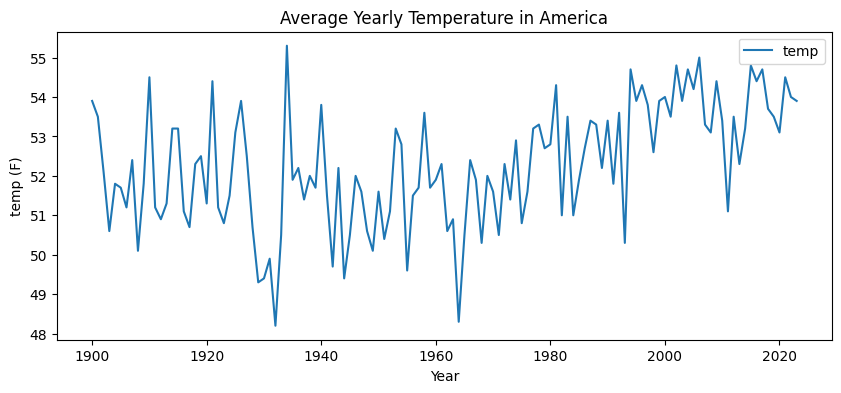

             temp
count  124.000000
mean    52.262903
std      1.534083
min     48.200000
25%     51.175000
50%     52.200000
75%     53.500000
max     55.300000


In [11]:
# Plotting
avtemp_df.plot(figsize=(10, 4))
plt.title("Average Yearly Temperature in America")
plt.ylabel("temp (F)")
plt.show()

# Computing summary statistics
print(avtemp_df.describe())

### Sea Ice Levels

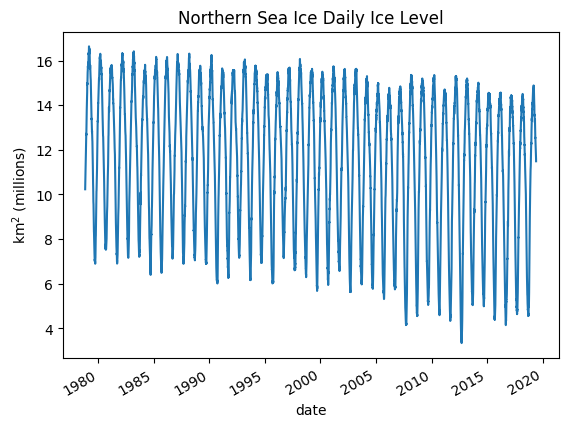

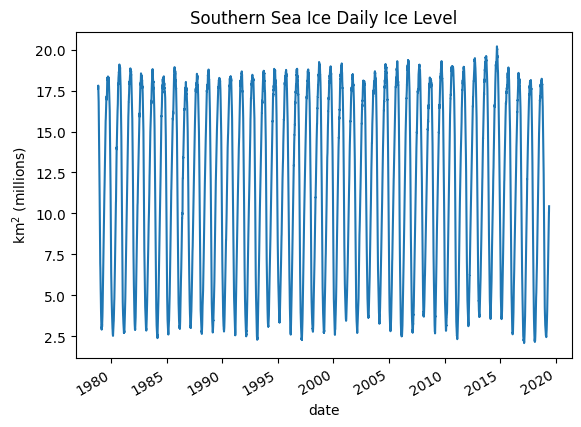

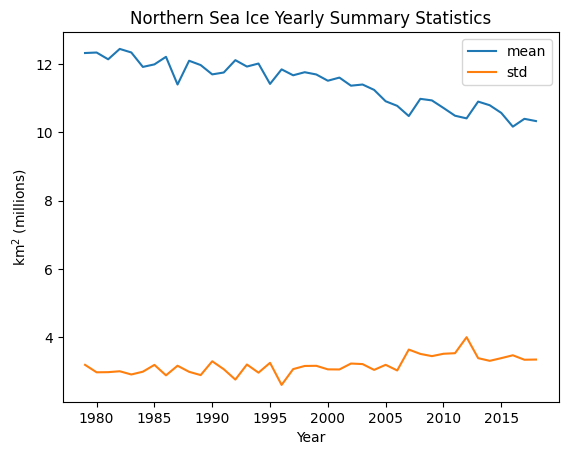

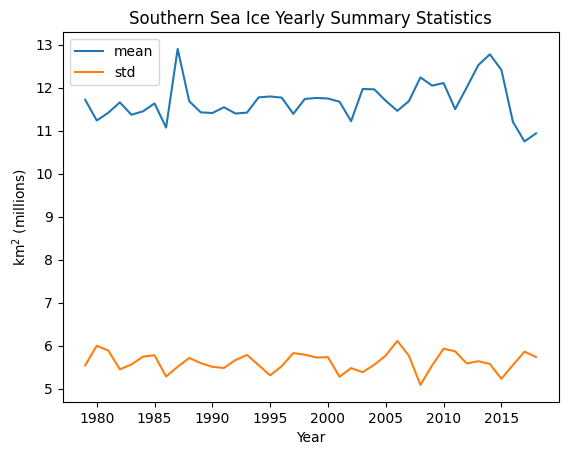

In [12]:
# Plotting the full statistics
seaice_df[seaice_df["hemisphere"] == "north"]["Extent"].plot()
plt.title("Northern Sea Ice Daily Ice Level")
plt.ylabel(r"$\text{km}^2$ (millions)")
plt.show()

seaice_df[seaice_df["hemisphere"] == "south"]["Extent"].plot()
plt.title("Southern Sea Ice Daily Ice Level")
plt.ylabel(r"$\text{km}^2$ (millions)")
plt.show()

# Plotting the summary statistics
seaice_north_yearly_df.plot()
plt.title("Northern Sea Ice Yearly Summary Statistics")
plt.ylabel(r"$\text{km}^2$ (millions)")
plt.show()

seaice_south_yearly_df.plot()
plt.title("Southern Sea Ice Yearly Summary Statistics")
plt.ylabel(r"$\text{km}^2$ (millions)")
plt.show()